In [1]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

shap.initjs()


In [2]:
model = joblib.load('../models/best_model.pkl')

X_test=np.load('../data/processed/X_test.npy')
y_test=np.load('../data/processed/y_test.npy')

feature_names=pd.read_csv('../data/processed/feature_names.csv')

X_test_df=pd.DataFrame(X_test,columns=feature_names)
print(f"Test set shape: {X_test_df.shape}")
print(f"Features: {feature_names[:5]}...")

Test set shape: (93987, 30)
Features:     0
0  V1
1  V2
2  V3
3  V4
4  V5...


In [3]:
explainer=shap.TreeExplainer(model)

print('Calculating SHAP values...(This may take a moment)')
shap_values=explainer.shap_values(X_test_df)

print(f'Shap values shape: {np.array(shap_values).shape}')
print('Done')

Calculating SHAP values...(This may take a moment)
Shap values shape: (93987, 30)
Done


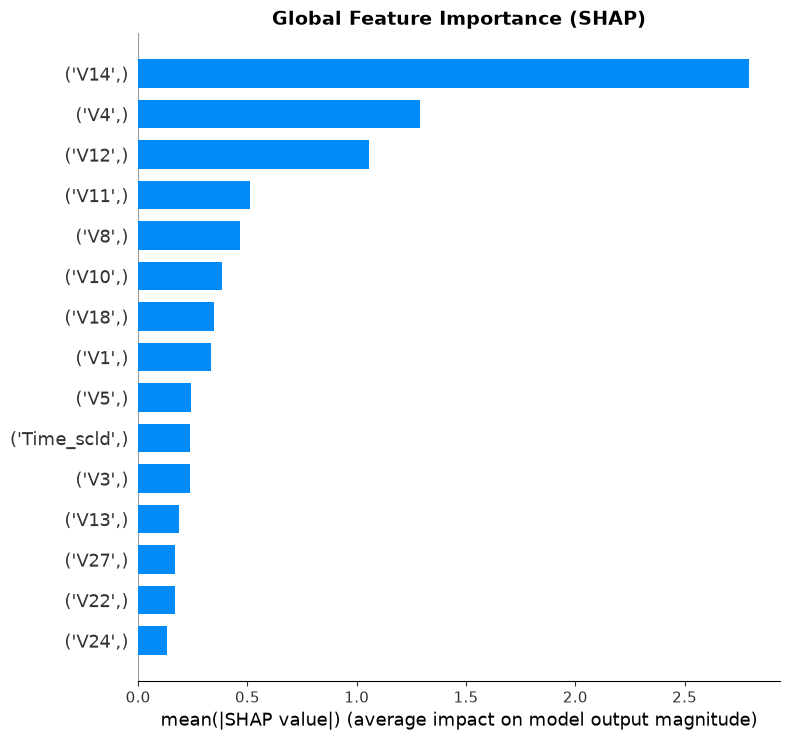

Saved ✓


In [4]:
plt.figure()
shap.summary_plot(
    shap_values[1] if isinstance(shap_values, list) else shap_values,
    X_test_df,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("Global Feature Importance (SHAP)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/shap_global_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved ✓")

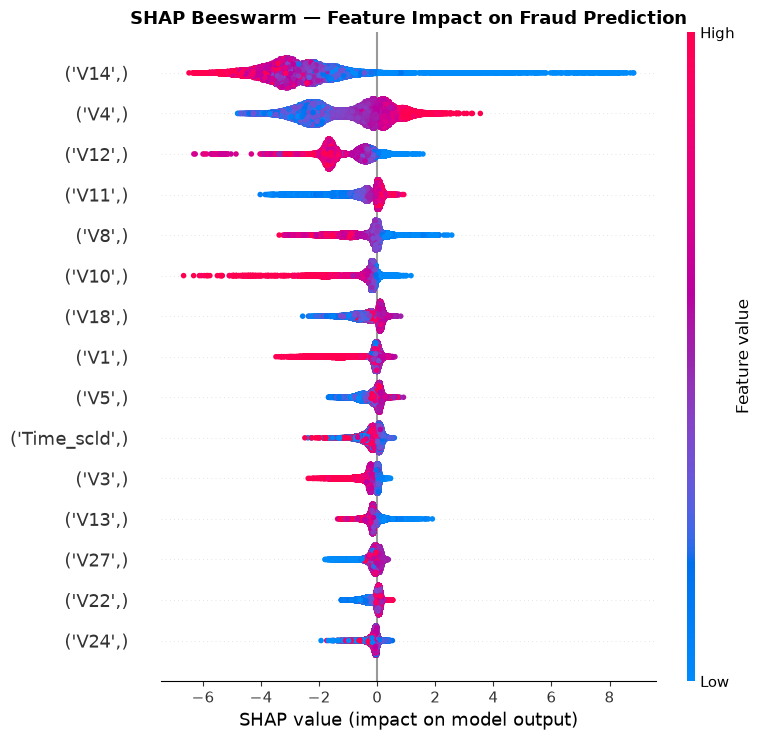

In [5]:
plt.figure()
shap.summary_plot(
    shap_values[1] if isinstance(shap_values, list) else shap_values,
    X_test_df,
    max_display=15,
    show=False
)
plt.title("SHAP Beeswarm — Feature Impact on Fraud Prediction", 
        fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()

Total fraud cases in test set: 162


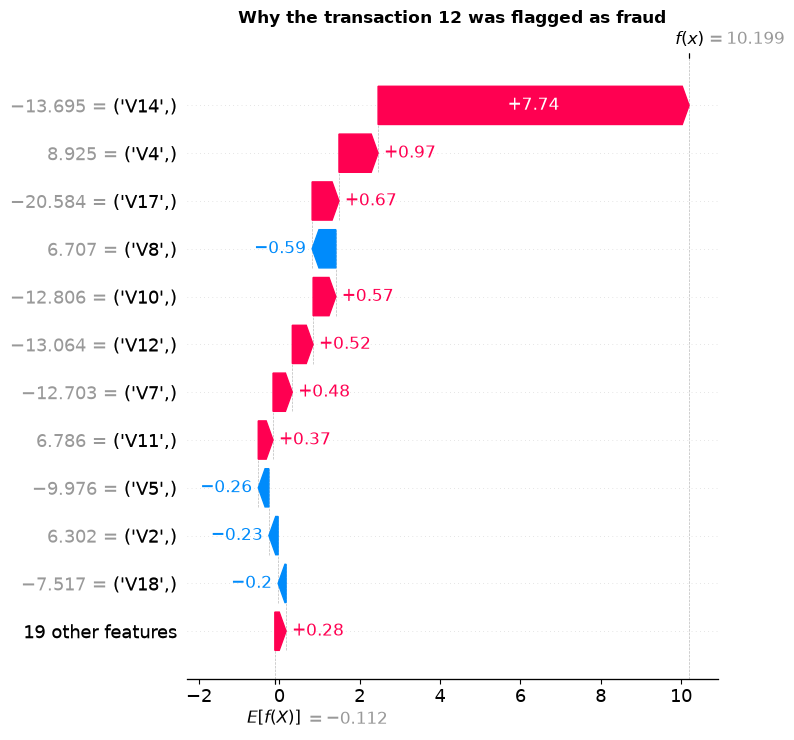

In [32]:
#Explain a single fraud transaction(Waterfall plot)


#Let's find actual fraud cases in test set
fraud_indices=np.where(y_test==1)[0]
print(f'Total fraud cases in test set: {len(fraud_indices)}')

#Pick first fraud case
fraud_idx = fraud_indices[0]

#Get the shap values for this transaction
sv=shap_values[1] if isinstance(shap_values,list) else shap_values
single_shap = sv[fraud_idx]
base_value=explainer.expected_value[1] if isinstance(explainer.expected_value,list) else explainer.expected_value

#Create explanation object
explanation=shap.Explanation(
    values=single_shap,
    base_values=base_value,
    data=X_test_df.iloc[fraud_idx].values,
    feature_names=X_test_df.columns
)

#Waterfall plot
plt.figure()
shap.waterfall_plot(explanation,max_display=12,show=False)
plt.title(f'Why the transaction {fraud_idx} was flagged as fraud',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig('../models/shap_waterfall_fraud.png',bbox_inches='tight',dpi=150)
plt.show()

Total legit cases in test set: 93825


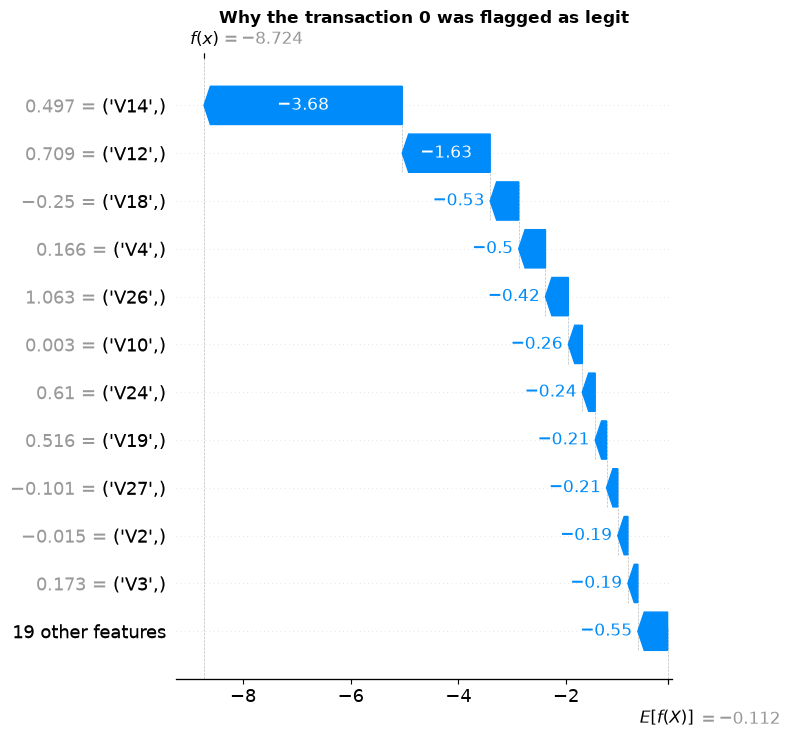

In [34]:
#Explain a single Legitimate transaction(Waterfall plot)


#Let's find actual LEGIIT cases in test set
legit_indices=np.where(y_test==0)[0]
print(f'Total legit cases in test set: {len(fraud_indices)}')

#Pick first LEGIT case
legit_idx = legit_indices[0]

#Get the shap values for this transaction
sv=shap_values[1] if isinstance(shap_values,list) else shap_values
single_shap = sv[legit_idx]
base_value=explainer.expected_value[1] if isinstance(explainer.expected_value,list) else explainer.expected_value

#Create explanation object
explanation=shap.Explanation(
    values=single_shap,
    base_values=base_value,
    data=X_test_df.iloc[legit_idx].values,
    feature_names=X_test_df.columns
)

#Waterfall plot
plt.figure()
shap.waterfall_plot(explanation,max_display=12,show=False)
plt.title(f'Why the transaction {legit_idx} was flagged as legit',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig('../models/shap_waterfall_legit.png',bbox_inches='tight',dpi=150)
plt.show()

In [41]:
mean_shap=np.abs(sv).mean(axis=0)
top_feature_idx=np.argmax(mean_shap)
top_feature=feature_names[top_feature_idx]

print(f"Top Feature: {top_feature}")

plt.figure(figsize=(8,5))
shap.dependence_plot(
    feature_names,
    sv,
    X_test_df,
    show=False
)
plt.title(f"Shap Dependence Plot--{top_feature}",fontsize=13)
plt.tight_layout()
plt.savefig('../models/shap_dependence.png',bbox_inches='tight',dpi=150)
plt.show()

KeyError: np.int64(13)